brain tumor

In [2]:
import torch
print("CUDA available:", torch.cuda.is_available())

CUDA available: True


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
import json

kaggle_creds = {
    "username": "Nick421421412",
    "key": "KGAT_840538bc6d7f298917acecec3e5f972c"
}

import os
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_creds, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)

print("Saved.")

Saved.


In [8]:
print(os.listdir('/root/.kaggle'))

!kaggle datasets download -d masoudnickparvar/brain-tumor-mri-dataset -p /content/BrainTumorData --unzip

['kaggle.json']
Dataset URL: https://www.kaggle.com/datasets/masoudnickparvar/brain-tumor-mri-dataset
License(s): Attribution 4.0 International (CC BY 4.0)
100% 157M/157M [00:09<00:00, 17.3MB/s]



In [10]:
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_full = datasets.ImageFolder(root='/content/BrainTumorData/Training', transform=train_transform)
test_set   = datasets.ImageFolder(root='/content/BrainTumorData/Testing', transform=eval_transform)

class_names = train_full.classes
print("Classes:", class_names)

val_size = int(0.1 * len(train_full))
train_size = len(train_full) - val_size
train_set, val_set = random_split(train_full, [train_size, val_size])

print(f"Train: {len(train_set)}, Val: {len(val_set)}, Test: {len(test_set)}")

Classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Train: 5040, Val: 560, Test: 1600


In [11]:
train_loader = DataLoader(train_set, batch_size=32, shuffle=True)
val_loader = DataLoader(val_set, batch_size=32, shuffle=False)
test_loader = DataLoader(test_set, batch_size=32, shuffle=False)

In [12]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(weights='IMAGENET1K_V2')

for param in model.parameters():
    param.requires_grad = False

model.fc = nn.Linear(model.fc.in_features, len(class_names))
model = model.to('cuda')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 128MB/s]


In [13]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=0.001)

num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Epoch {epoch+1}/{num_epochs} — Loss: {running_loss/len(train_loader):.4f} — Val Acc: {val_acc:.4f}")

Epoch 1/10 — Loss: 0.7448 — Val Acc: 0.8357
Epoch 2/10 — Loss: 0.4664 — Val Acc: 0.8768
Epoch 3/10 — Loss: 0.3972 — Val Acc: 0.8857
Epoch 4/10 — Loss: 0.3496 — Val Acc: 0.9036
Epoch 5/10 — Loss: 0.3295 — Val Acc: 0.8946
Epoch 6/10 — Loss: 0.3188 — Val Acc: 0.8929
Epoch 7/10 — Loss: 0.2957 — Val Acc: 0.9196
Epoch 8/10 — Loss: 0.2888 — Val Acc: 0.9179
Epoch 9/10 — Loss: 0.2719 — Val Acc: 0.9214
Epoch 10/10 — Loss: 0.2571 — Val Acc: 0.9179


In [14]:
for param in model.parameters():
    param.requires_grad = True

optimizer = optim.Adam(model.parameters(), lr=0.0001)

num_epochs_finetune = 5

for epoch in range(num_epochs_finetune):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to('cuda'), labels.to('cuda')
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to('cuda'), labels.to('cuda')
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    val_acc = correct / total
    print(f"Fine-tune Epoch {epoch+1}/{num_epochs_finetune} — Loss: {running_loss/len(train_loader):.4f} — Val Acc: {val_acc:.4f}")

Fine-tune Epoch 1/5 — Loss: 0.1699 — Val Acc: 0.9821
Fine-tune Epoch 2/5 — Loss: 0.0614 — Val Acc: 0.9786
Fine-tune Epoch 3/5 — Loss: 0.0392 — Val Acc: 0.9786
Fine-tune Epoch 4/5 — Loss: 0.0287 — Val Acc: 0.9804
Fine-tune Epoch 5/5 — Loss: 0.0250 — Val Acc: 0.9821


              precision    recall  f1-score   support

      glioma       1.00      0.77      0.87       400
  meningioma       0.86      0.99      0.92       400
     notumor       0.94      1.00      0.97       400
   pituitary       0.99      1.00      1.00       400

    accuracy                           0.94      1600
   macro avg       0.95      0.94      0.94      1600
weighted avg       0.95      0.94      0.94      1600



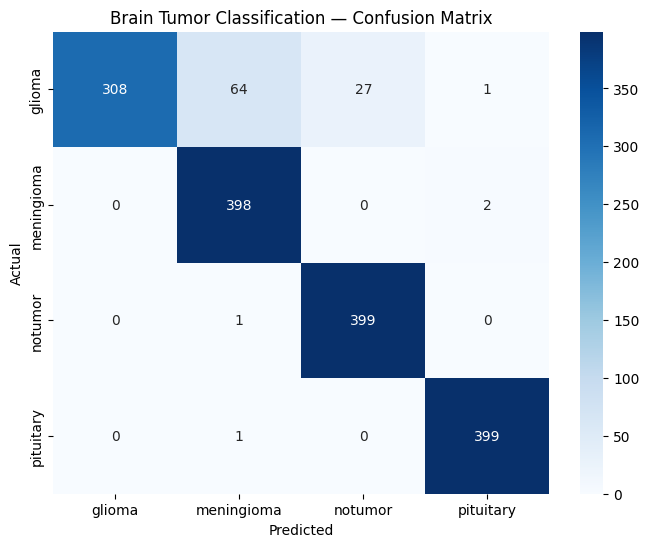

In [15]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

model.eval()
all_preds, all_labels = [], []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to('cuda')
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=class_names))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Brain Tumor Classification — Confusion Matrix')
plt.savefig('/content/drive/MyDrive/brain_tumor_confusion_matrix.png')
plt.show()

In [16]:
torch.save({
    'model_state_dict': model.state_dict(),
    'class_names': class_names
}, '/content/drive/MyDrive/brain_tumor_model.pt')

print("Saved to /content/drive/MyDrive/brain_tumor_model.pt")

Saved to /content/drive/MyDrive/brain_tumor_model.pt
